# Cloud mask experiments
This notebook compares several cloud-masking strategies for Sentinel-2 L2A.

- **Threshold-based**: Adapted from the `isCloud` logic in [Wildfire Visualization](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/markuse_fire/).
- **SCL dilation (openEO `to_scl_dilation_mask`)**: Builds a cloud mask from SCL classes and expands it to remove neighboring pixels (cloud edges / adjacency effects).

Masked pixels become missing values; this notebook uses a **median** composite across timestamps to reduce gaps.

In [2]:
import openeo
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from openeo.processes import array_create, if_, or_, and_, not_, neq

## Connect to Coperncius (CDSE) OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. The spatial extent below corresponds to 

In [3]:
spatial_extent = {"west" : -100.80, "south" : 37.94, "east" : -100.61, "north" : 38.03}

## Threshold-based Cloud Mask
- Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/markuse_fire/
- Pros:
    - Fast and lightweight: only requires a few bands, easy to run in openEO at scale
    - Transparent logic: thresholds and formulas are explicit and easy to audit/tune
    - No training data needed
    - Can work reasonably in bright smoke/fire contexts (the source script is built for that)
- Cons: 
    - Threshold sensitivity: fixed constants may not transfer well across seasons, latitudes, and surfaces
    - Limited spectral context: no SWIR/cirrus/thermal features, so confusion increases for bright soil, snow, haze, sunlight, urban roofs
    - Thin cloud / haze leakage: semi-transparent cloud and aerosol may pass the filter
    - Potential false cloud over bright targets: can mask valid vegetation-adjacent bright pixels (in relation to NDVI calculation)
    - No explicit cloud shadow handling: shadows can remain and depress reflectance
    - Deterministic, not probabilistic

### Load Sentinel-2 L2A Data

In [4]:
# The initial time range to evaluate data availability and their acquisition dates
selected_date = "2020-05-20"

# Convert to datetime objects
dt_format = "%Y-%m-%d"
sel_date = datetime.strptime(selected_date, dt_format)

# 5 days before and after
dt_minus_5 = sel_date - timedelta(days=5)
dt_plus_5 = sel_date + timedelta(days=5)

# Turn them to string
dt_minus_5 = str(dt_minus_5.date())
dt_plus_5 = str(dt_plus_5.date())

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[dt_minus_5, dt_plus_5],
    bands=["B02", "B03", "B04", "SCL"]
)

### Threshold-based cloud masking logic

In [5]:
avoidanceHelper = 0.8

def isCloud(band_B03, band_B04):
    NGDR = (band_B03 - band_B04) / (band_B03 + band_B04)
    bRatio = (band_B03 - 0.175) / (0.39 - 0.175)
    return or_(bRatio > 1, and_(bRatio > 0, NGDR > 0))

def cloud_free_image(data):
    B02, B03, B04 = (data[0], data[1], data[2])

    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000

    clp = isCloud(B03, B04)

    cloud_free_mask = and_(not_(clp), B02 < avoidanceHelper)

    cloud_free = array_create(
        [
            if_(cloud_free_mask, B04, None),
            if_(cloud_free_mask, B03, None),
            if_(cloud_free_mask, B02, None),
        ]
    )

    return cloud_free

In [6]:
masked = s2cube.apply_dimension(dimension="bands", process=cloud_free_image)

# Get the median across time arrays to fill None values 
threshold_based_cloud_free = masked.reduce_dimension(dimension="t", reducer="median")

# threshold_based_cloud_free = threshold_based_cloud_free.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

threshold_based_cloud_free = threshold_based_cloud_free.save_result("GTiff")

In [7]:
threshold_based_cloud_free.download("threshold_based_cloud_free.tif")

## Using `to_scl_dilation_mask`
- Sources:
    - [Parcel delineation using Sentinel-2](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/ParcelDelineation/Parcel%20delineation.html#select-usable-observations)
    - [Debugging results from `to_scl_dilation_mask`](https://forum.dataspace.copernicus.eu/t/to-scl-dilation-mask-produces-odd-borders/1298)
    - [`to_scl_dilation_mask` doc](https://docs.openeo.cloud/processes/#to_scl_dilation_mask)
- Pros:
    - Dilation expands cloudy areas, so thin cloud edges, haze, and many shadows could be removed, better than with raw SCL category masking
    - Reproducible: using a built-in process with explicit parameters, make it easier to document and repeat than ad-hoc thresholds
- Cons:
    - Not cloud agnostic, it's backend- and product-dependent (`to_scl_dilation_mask` possibly only work in CDSE, and SCL is only available in Sentinel-L2A product hosted in CDSE)

### Load Bands and SCL Separately from Sentinel-2 L2A

In [38]:
# The initial time range to evaluate data availability and their acquisition dates
selected_date = "2020-05-20"

# Convert to datetime objects
dt_format = "%Y-%m-%d"
sel_date = datetime.strptime(selected_date, dt_format)

# 5 days before and after
dt_minus_5 = sel_date - timedelta(days=5)
dt_plus_5 = sel_date + timedelta(days=5)

# Turn them to string
dt_minus_5 = str(dt_minus_5.date())
dt_plus_5 = str(dt_plus_5.date())

scl = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[dt_minus_5, dt_plus_5],
    bands=["SCL"]
)

# Following the default in https://docs.openeo.cloud/processes/#to_scl_dilation_mask
cloud_mask = scl.process(
    "to_scl_dilation_mask",
    data=scl,
    kernel1_size=17, kernel2_size=31,
    mask1_values=[2, 4, 5, 6, 7],
    mask2_values=[3, 8, 9, 10, 11], 
    erosion_kernel_size=0
)

In [ ]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[dt_minus_5, dt_plus_5],
    bands=["B04", "B03", "B02"]
)

# Scaling band values to 0 - 1
s2cube = s2cube.apply_dimension(dimension="bands", process= lambda data: data / 10000)

s2cube_masked = s2cube.mask(cloud_mask)

s2cube_masked = s2cube_masked.reduce_dimension(dimension="t", reducer="median")

# Casting to floats
s2cube_masked = s2cube_masked * 1.0

s2cube_masked = s2cube_masked.save_result("GTiff")

In [40]:
s2cube_masked.download("scl_dilation_cloud_free.tif")

## Evaluation

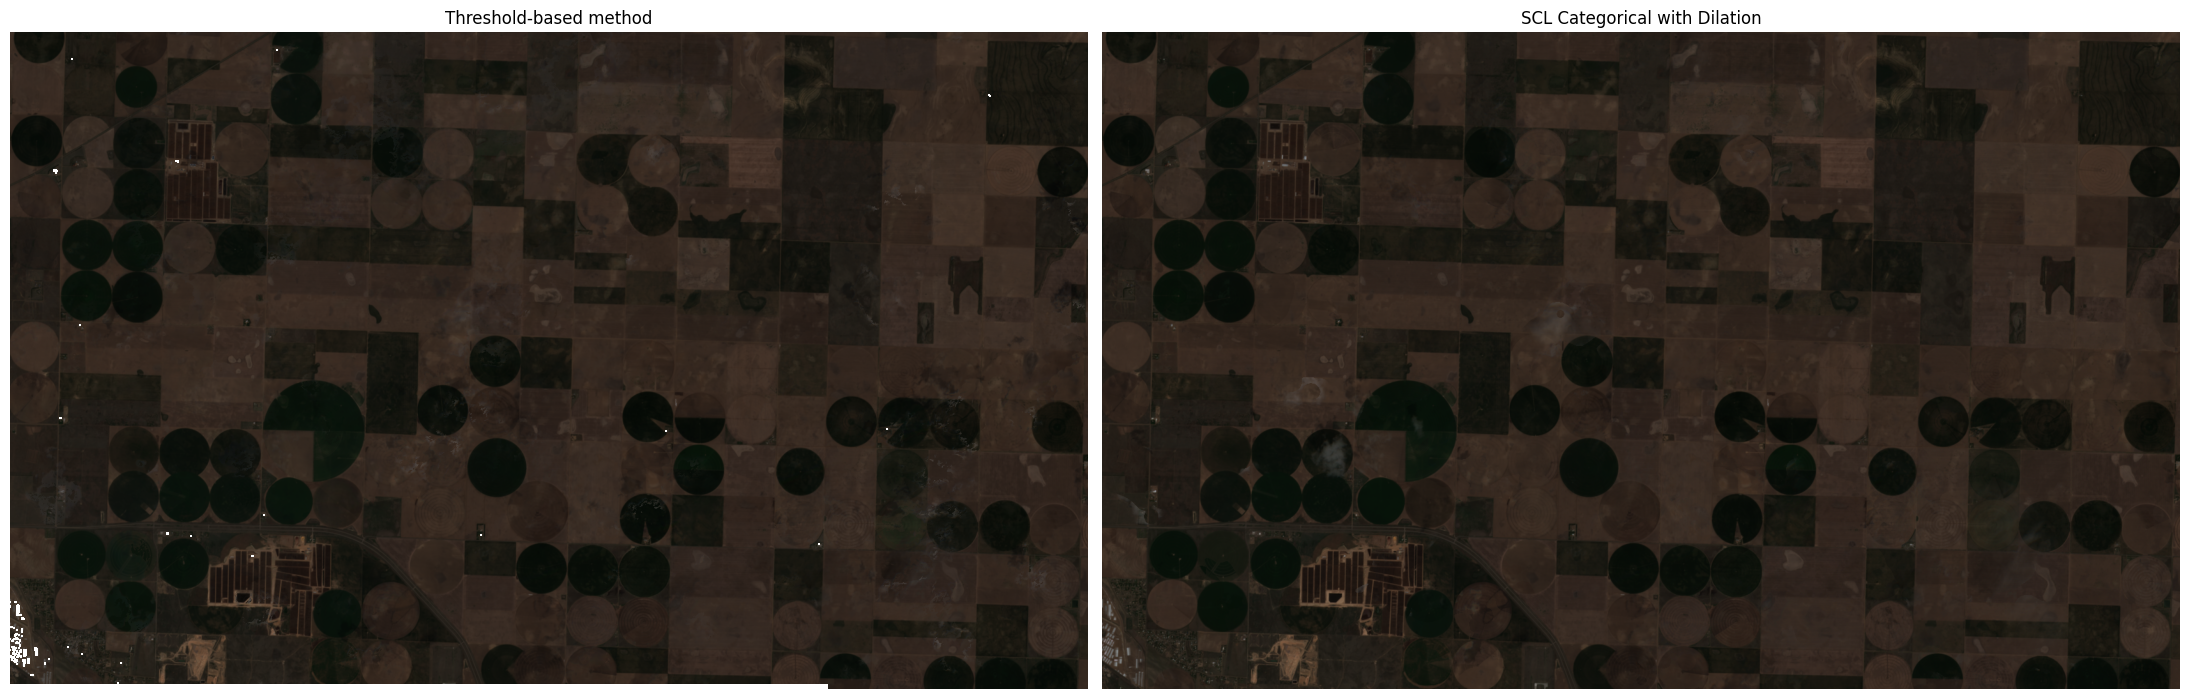

In [11]:
ds_threshold = rioxarray.open_rasterio("threshold_based_cloud_free.tif")
ds_dilation = rioxarray.open_rasterio("scl_dilation_cloud_free.tif")

rgb_threshold = np.stack([
    ds_threshold.sel(band=1).values,
    ds_threshold.sel(band=2).values,
    ds_threshold.sel(band=3).values
], axis=-1)

rgb_dilation = np.stack([
    ds_dilation.sel(band=3).values,
    ds_dilation.sel(band=2).values,
    ds_dilation.sel(band=1).values
], axis=-1)

rgb_threshold = np.clip(rgb_threshold, 0, 1)
rgb_dilation = np.clip(rgb_dilation, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.subplots_adjust(hspace=-0.5, wspace=0.05)

axes[0].imshow(
    rgb_threshold,
    extent=[
        ds_threshold.x.values.min(),
        ds_threshold.x.values.max(),
        ds_threshold.y.values.min(),
        ds_threshold.y.values.max(),
    ],
)
axes[0].set_title("Threshold-based method")

axes[1].imshow(
    rgb_dilation,
    extent=[
        ds_dilation.x.values.min(),
        ds_dilation.x.values.max(),
        ds_dilation.y.values.min(),
        ds_dilation.y.values.max(),
    ],
)
axes[1].set_title("SCL Categorical with Dilation")

# Remove axis labels
for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()